In [1]:
import numpy as np

### Barrett-kok
Resulting Entanglement is given by

$$
F_{\text{entangle}} = \frac{1}{2} \left( 1 + \frac{(C + 1)^2 \gamma^2}{((C + 1)\gamma + 2\gamma^*)^2 + \Delta_{\omega}^2} \right)
$$


In [2]:
class Node:
    """
    A class representing a node in a quantum network.
    C = atom-cavity cooperativity
    decay_rate = decay rate of the cavity i.e. gamma
    dephasing_rate = dephasing rate of the atom i.e. gamma*
    delta = denotes the difference between the optical transition frequencies
    fidelity = list containing fidelity of each memory
    memory_status = list containing the status of each memory "self" for the self node and the name of the node for other nodes
    """
    def __init__(self, no_of_memories, name, C=50, decay_rate=1, dephasing_rate=0.1, delta=0.1):
        self.name = name
        self.no_of_memories = no_of_memories
        self.fidelity = []
        self.memory_status = ["self"] * no_of_memories
        f = self.calculate_fidelity(C, decay_rate, dephasing_rate, delta)
        self.fidelity = [f] * no_of_memories

    def calculate_fidelity(self, C, decay_rate, dephasing_rate, delta):
        ##Equation 1 in the sequence paper
        numerator = (C + 1)**2 * decay_rate**2
        denominator = ((C + 1) * decay_rate + 2 * dephasing_rate)**2 + delta**2
        return 0.5 * (1 + (numerator / denominator))

In [3]:
#Example usage
# r1 = Node(10, "r1")
# print(r1.fidelity)

In [ ]:
class Channel:
    def __init__(self, node1, node2, dist, attenuation = 1e-05):
        self.node1 = node1
        self.node2 = node2
        self.dist = dist
        self.attenuation = attenuation
        self.loss = 1 - (10 * (self.dist * self.attenuation / -10))

## Loss in Fidelity is given by:

##### 1. Quality of Initial Entanglement (i.e. $F_1$ and $F_2$)
##### 2. Hardware imperfection given by $F_d$ i.e. fidelity degredation per swap
##### 3. Decoherence time of the memory (T_2) given by $e^{-L/T2*c}$
The resulting fidelity is given by:

$$F_{result} = F_1 * F_2 * decoherence^2 * F_d * n$$

Where n is the number of swaps
## Photon loss in transmission 
A photon is lost and the memory isn't entangled if the following condition is met:

$$random.random() <= 10^{-L*\alpha/10} $$

In [5]:
import random
import math

def swap(node1, node2, no_memory, path_details):
    """
    Simulates end-to-end entanglement generation and swapping between two nodes.
    
    Args:
        node1, node2: The Node objects (must have memory_status and fidelity lists)
        no_memory: The exact number of entangled memory pairs requested.
        path_details: The path extracted from your routing table. 
                      Expected format: list of tuples (source_name, dest_name, distance_km)
                      Example: [("r1", "r2", 10), ("r2", "r3", 15)]
    
    Returns:
        int: The number of successfully entangled memory pairs.
    """
    
    # ==========================================
    # 1. Check for Free Memories
    # ==========================================
    free_idx1 = [i for i, status in enumerate(node1.memory_status) if status == "self"]
    free_idx2 = [i for i, status in enumerate(node2.memory_status) if status == "self"]
    
    if len(free_idx1) < no_memory or len(free_idx2) < no_memory:
        raise ValueError(
            f"Not enough free memories! {node1.name} has {len(free_idx1)}, "
            f"{node2.name} has {len(free_idx2)}. Requested: {no_memory}"
        )

    # ==========================================
    # 2. Extract Path Data from Routing Table
    # ==========================================
    total_distance_km = sum(distance for _, _, distance in path_details)
    num_channels = len(path_details)
    num_swaps = num_channels - 1
    if num_channels == 0:
        raise ValueError("Path is empty!")

    # ==========================================
    # 3. Physics & Hardware Constants
    # ==========================================
    F_d = 0.95                    # Hardware fidelity degradation per swap
    attenuation = 1e-05             # Fiber loss in dB/km (standard telecom fiber)
    c_fiber = 200000              # Speed of light in fiber (km/s)
    T2 = 0.120                    # Memory Coherence Time in seconds (120 ms)

    # ==========================================
    # 4. Calculate Loss & Decoherence Factors
    # ==========================================
    # Success probability based on total attenuation
    # Formula: 10^(-(loss_per_km * distance) / 10)
    success_probability = 10 ** (-(attenuation * total_distance_km) / 10.0)
    wait_time = total_distance_km / c_fiber #how long it takes the photon to travel the distance
    
    # Decoherence factor: e^(-t / T2)
    decoherence = math.exp(-wait_time / T2)
    
    # Multi-hop degradation penalty (F_d applied for every swap station)
    total_swap_penalty = F_d ** num_swaps if num_swaps > 0 else 1.0

    successful_swaps = 0

    # ==========================================
    # 5. Perform the Swaps
    # ==========================================
    for i in range(no_memory):
        idx1 = free_idx1[i]
        idx2 = free_idx2[i]
        
        # Probabilistic check: Did the photons survive the fiber loss?
        if random.random() <= success_probability:
            
            # Fetch the starting fidelities
            F1 = node1.fidelity[idx1]
            F2 = node2.fidelity[idx2]
            
            # Calculate final fidelity
            # Formula: Penalty * F1 * F2 * (Decoherence ^ 2)
            F_final = total_swap_penalty * F1 * F2 * (decoherence ** 2)
            
            # Update memory statuses to point to each other
            node1.memory_status[idx1] = node2.name
            node2.memory_status[idx2] = node1.name
            
            # Update the fidelities to the decayed/swapped value
            node1.fidelity[idx1] = F_final
            node2.fidelity[idx2] = F_final
            
            successful_swaps += 1
            
        else:
            # The photons were lost in transmission. 
            # Status remains "self", they can be tried again next cycle.
            pass
            
    print(f"Swap attempt {node1.name} <-> {node2.name}: {successful_swaps}/{no_memory} succeeded.")
    print(f"Final Fidelity of successful links: {F_final:.4f}" if successful_swaps > 0 else "")
    
    return successful_swaps    

In [6]:
r1 = Node(10, "r1")
r2 = Node(10, "r2")
r3 = Node(10, "r3")
r4 = Node(10, "r4")
r5 = Node(10, "r5")

In [7]:
swap(r1, r3, 5, [('r1', 'r5', 500), ('r5', 'r3', 200)])

r1.fidelity

Swap attempt r1 <-> r3: 5/5 succeeded.
Final Fidelity of successful links: 0.8892


[0.8891912764053513,
 0.8891912764053513,
 0.8891912764053513,
 0.8891912764053513,
 0.8891912764053513,
 0.9960994869251749,
 0.9960994869251749,
 0.9960994869251749,
 0.9960994869251749,
 0.9960994869251749]

In [8]:
swap(r1, r4, 3, [('r1', 'r5', 500), ('r5', 'r4', 166.66666666666667)])

Swap attempt r1 <-> r4: 3/3 succeeded.
Final Fidelity of successful links: 0.8917


3

In [9]:
import matplotlib.pyplot as plt

def plot_fidelities(node):
    """
    Plots the fidelity versus the index of the memory for a given Node,
    ignoring memories that are still marked as "self" (unentangled).
    """
    entangled_indices = []
    entangled_fidelities = []
    
    for idx, status in enumerate(node.memory_status):
        if status != "self":
            entangled_indices.append(idx)
            entangled_fidelities.append(node.fidelity[idx])
            
    if not entangled_indices:
        print(f"[{node.name}] No entangled memories to plot.")
        return
        
    plt.figure(figsize=(8, 5))
    plt.bar(entangled_indices, entangled_fidelities, color='#0284c7', edgecolor='black')
    plt.xlabel('Memory Index', fontsize=12)
    plt.ylabel('Fidelity', fontsize=12)
    plt.title(f'Entangled Memory Fidelities for Node: {node.name}', fontsize=14)
    plt.ylim(0.0, 1.05)  # Keep the Y-axis scaled appropriately for fidelities (0 to 1)
    plt.xticks(entangled_indices) # Only show ticks for memories that are actually entangled
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

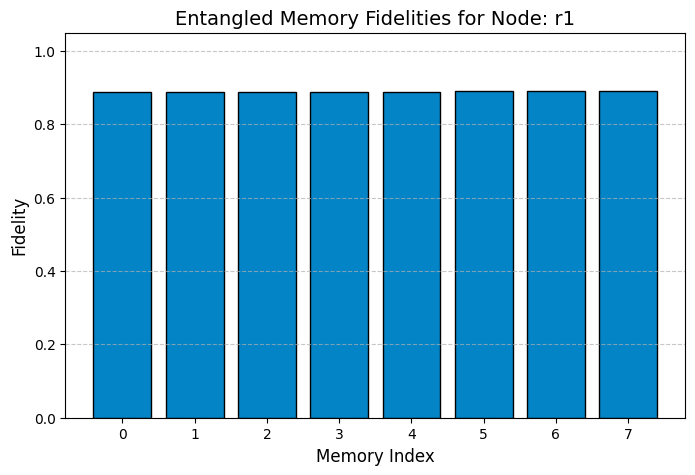

In [10]:
plot_fidelities(r1)

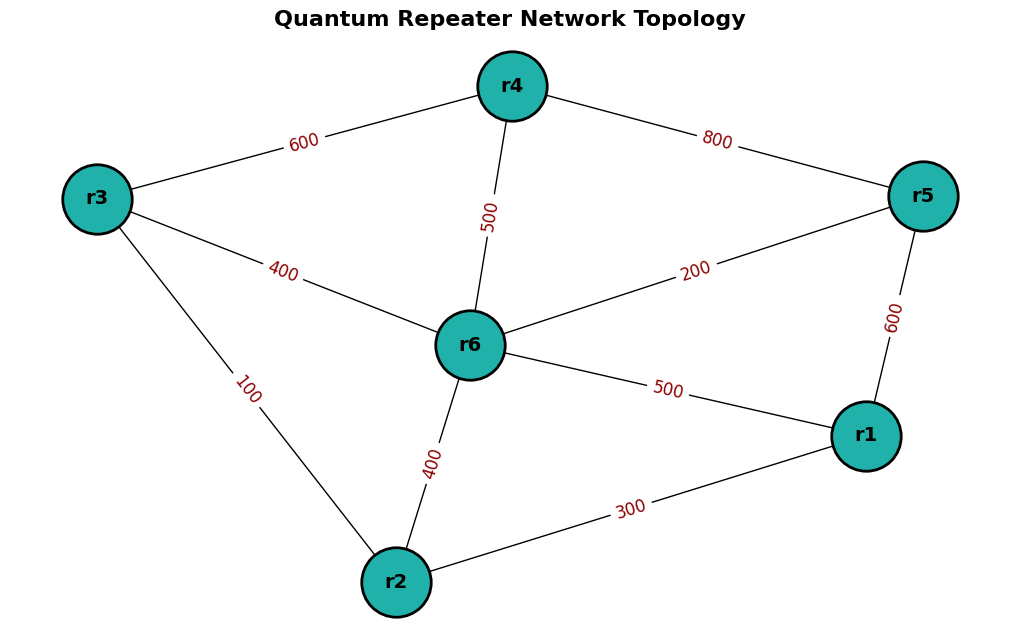

In [11]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Initialize an undirected graph
quantum_network = nx.Graph()

# 2. Define the edges and their weights (distances in km) based on your image
# Format: (Node_A, Node_B, Weight)
edges = [
    ("r1", "r2", 300),
    ("r1", "r6", 500),
    ("r1", "r5", 600),
    ("r2", "r3", 100),
    ("r2", "r6", 400),
    ("r3", "r6", 400),
    ("r3", "r4", 600),
    ("r4", "r6", 500),
    ("r4", "r5", 800),
    ("r5", "r6", 200)
]

# Add the edges to the graph
quantum_network.add_weighted_edges_from(edges)

# ==========================================
# Visualization (Perfect for your Jupyter Notebook)
# ==========================================

plt.figure(figsize=(10, 6))

# Generate a layout for the nodes. 
# Using a fixed seed ensures the graph looks the same every time you plot it.
pos = nx.spring_layout(quantum_network, seed=42) 

# Draw the nodes
nx.draw(quantum_network, pos, 
        with_labels=True, 
        node_color='lightseagreen', 
        node_size=2500, 
        font_size=14, 
        font_weight='bold', 
        edgecolors='black', 
        linewidths=2)

# Extract weights and draw the edge labels
edge_labels = nx.get_edge_attributes(quantum_network, 'weight')
nx.draw_networkx_edge_labels(quantum_network, pos, 
                             edge_labels=edge_labels, 
                             font_size=12, 
                             font_color='darkred')

plt.title("Quantum Repeater Network Topology", fontsize=16, fontweight='bold')
plt.axis('off') # Hides the x and y axes for a cleaner look
plt.show()

In [12]:
r1 = Node(10, "r1")
r2 = Node(10, "r2")
r3 = Node(10, "r3")
r4 = Node(10, "r4")
r5 = Node(10, "r5")
r6 = Node(10, "r6")

In [13]:
swap(r1, r2, 1, [('r1', 'r2', 3000)])
swap(r1, r6, 1, [('r1', 'r6', 5000)])
swap(r1, r5, 1, [('r1', 'r5', 6000)])
swap(r2, r3, 1, [('r2', 'r3', 1000)])
swap(r2, r6, 1, [('r2', 'r6', 4000)])
swap(r3, r6, 1, [('r3', 'r6', 4000)])
swap(r3, r4, 1, [('r3', 'r4', 6000)])
swap(r4, r6, 1, [('r4', 'r6', 5000)])
swap(r4, r5, 1, [('r4', 'r5', 8000)])
swap(r5, r6, 1, [('r5', 'r6', 2000)])

Swap attempt r1 <-> r2: 1/1 succeeded.
Final Fidelity of successful links: 0.7727
Swap attempt r1 <-> r6: 1/1 succeeded.
Final Fidelity of successful links: 0.6541
Swap attempt r1 <-> r5: 1/1 succeeded.
Final Fidelity of successful links: 0.6018
Swap attempt r2 <-> r3: 1/1 succeeded.
Final Fidelity of successful links: 0.9129
Swap attempt r2 <-> r6: 1/1 succeeded.
Final Fidelity of successful links: 0.7110
Swap attempt r3 <-> r6: 1/1 succeeded.
Final Fidelity of successful links: 0.7110
Swap attempt r3 <-> r4: 1/1 succeeded.
Final Fidelity of successful links: 0.6018
Swap attempt r4 <-> r6: 1/1 succeeded.
Final Fidelity of successful links: 0.6541
Swap attempt r4 <-> r5: 1/1 succeeded.
Final Fidelity of successful links: 0.5094
Swap attempt r5 <-> r6: 1/1 succeeded.
Final Fidelity of successful links: 0.8399


1